In [1]:
# Cell 1: Kiểm tra Python version và GPU
import sys
import torch

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
PyTorch version: 2.5.1+cu124
CUDA available: True
GPU: Tesla T4
CUDA version: 12.4
GPU Memory: 15.83 GB


In [2]:
import os

# Tạo thư mục results
os.makedirs('/kaggle/working/results', exist_ok=True)

# Chuyển về working directory
os.chdir('/kaggle/working')

print("="*70)
print("CELL 1: SETUP DIRECTORIES")
print("="*70)
print(f"✅ Working directory: {os.getcwd()}")
print(f"✅ Results directory: /kaggle/working/results")
print("="*70)

CELL 1: SETUP DIRECTORIES
✅ Working directory: /kaggle/working
✅ Results directory: /kaggle/working/results


In [3]:
import os
import subprocess

print("="*70)
print("CELL 2: CLONE REPOSITORY")
print("="*70)

os.chdir('/kaggle/working')

# Xóa clone cũ
if os.path.exists('cobl'):
    import shutil
    shutil.rmtree('cobl')
    print("🗑️  Removed old clone")

# Clone
print("🔽 Cloning...")
subprocess.run(['git', 'clone', 'https://github.com/traananhdat/cobl'], check=True)

print("✅ Clone successful!")
print("\n📂 Repository files:")
os.chdir('/kaggle/working/cobl')
subprocess.run(['ls', '-la'])

# Save info
with open('/kaggle/working/results/02_clone.txt', 'w') as f:
    f.write("Clone successful\n")
    f.write(f"Path: /kaggle/working/cobl\n")

print("\n💾 Saved: /kaggle/working/results/02_clone.txt")
print("="*70)

CELL 2: CLONE REPOSITORY
🗑️  Removed old clone
🔽 Cloning...


Cloning into 'cobl'...


✅ Clone successful!

📂 Repository files:
total 44
drwxr-xr-x 6 root root 4096 Dec 25 14:36 .
drwxr-xr-x 5 root root 4096 Dec 25 14:36 ..
drwxr-xr-x 7 root root 4096 Dec 25 14:36 cobl
drwxr-xr-x 2 root root 4096 Dec 25 14:36 demo
drwxr-xr-x 8 root root 4096 Dec 25 14:36 .git
-rw-r--r-- 1 root root  126 Dec 25 14:36 .gitignore
-rwxr-xr-x 1 root root 2252 Dec 25 14:36 install.sh
-rw-r--r-- 1 root root 1072 Dec 25 14:36 LICENSE
drwxr-xr-x 2 root root 4096 Dec 25 14:36 media
-rw-r--r-- 1 root root 1458 Dec 25 14:36 README.md
-rw-r--r-- 1 root root  949 Dec 25 14:36 setup.py

💾 Saved: /kaggle/working/results/02_clone.txt


In [4]:
import os
import subprocess

print("="*70)
print("CELL 3: DOWNLOAD MODELS FROM DROPBOX")
print("="*70)

os.chdir('/kaggle/working/cobl')

# 1. Download SD v2.1 checkpoint
print("\n1️⃣  Downloading Stable Diffusion v2.1...")
os.makedirs('./cobl/LDM/SD2p1/', exist_ok=True)

sd_url = "https://www.dropbox.com/scl/fi/gigq3jln53alg8aalhsdn/v2-1_512-ema-pruned.ckpt?rlkey=absdglgiw5strfkdociwqdcw9&st=hx4tqbyb&dl=1"
sd_path = "./cobl/LDM/SD2p1/v2-1_512-ema-pruned.ckpt"

if os.path.exists(sd_path):
    print(f"   ✅ Already exists: {sd_path}")
else:
    print(f"   📥 Downloading (~5.2GB)...")
    subprocess.run(['curl', '-L', sd_url, '-o', sd_path], check=True)
    if os.path.exists(sd_path):
        size_gb = os.path.getsize(sd_path) / 1e9
        print(f"   ✅ Downloaded: {size_gb:.2f} GB")
    else:
        print("   ❌ Download failed!")

# 2. Download CoBL checkpoint
print("\n2️⃣  Downloading CoBL checkpoint...")
os.makedirs('./cobl/model/', exist_ok=True)

cobl_url = "https://www.dropbox.com/scl/fi/cirx1dh4hst6ar3o2w33h/cobl_added_params.ckpt?rlkey=2p9lqvqz9ae0djg9uthtari3p&st=sq05l8kn&dl=1"
cobl_path = "./cobl/model/cobl_added_params.ckpt"

if os.path.exists(cobl_path):
    print(f"   ✅ Already exists: {cobl_path}")
else:
    print(f"   📥 Downloading...")
    subprocess.run(['curl', '-L', cobl_url, '-o', cobl_path], check=True)
    if os.path.exists(cobl_path):
        size_mb = os.path.getsize(cobl_path) / 1e6
        print(f"   ✅ Downloaded: {size_mb:.2f} MB")
    else:
        print("   ❌ Download failed!")

# 3. Download U2Net checkpoint
print("\n3️⃣  Downloading U2Net checkpoint...")
os.makedirs('./cobl/U2Net/', exist_ok=True)

u2net_url = "https://www.dropbox.com/scl/fi/obpwapfgjl6gwmmwpc1le/u2net.pth?rlkey=0q0dqx17fk9yve3ve98ws9zy9&st=z6uuzf1c&dl=1"
u2net_path = "./cobl/U2Net/u2net.pth"

if os.path.exists(u2net_path):
    print(f"   ✅ Already exists: {u2net_path}")
else:
    print(f"   📥 Downloading...")
    subprocess.run(['curl', '-L', u2net_url, '-o', u2net_path], check=True)
    if os.path.exists(u2net_path):
        size_mb = os.path.getsize(u2net_path) / 1e6
        print(f"   ✅ Downloaded: {size_mb:.2f} MB")
    else:
        print("   ❌ Download failed!")

# Save summary
with open('/kaggle/working/results/03_downloads.txt', 'w') as f:
    f.write("Model Downloads Summary\n")
    f.write("="*50 + "\n")
    f.write(f"SD v2.1: {'✅' if os.path.exists(sd_path) else '❌'} {sd_path}\n")
    f.write(f"CoBL: {'✅' if os.path.exists(cobl_path) else '❌'} {cobl_path}\n")
    f.write(f"U2Net: {'✅' if os.path.exists(u2net_path) else '❌'} {u2net_path}\n")

print("\n💾 Saved: /kaggle/working/results/03_downloads.txt")
print("="*70)

CELL 3: DOWNLOAD MODELS FROM DROPBOX

1️⃣  Downloading Stable Diffusion v2.1...
   📥 Downloading (~5.2GB)...


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    17  100    17    0     0     30      0 --:--:-- --:--:-- --:--:--    30
100   496    0   496    0     0    451      0 --:--:--  0:00:01 --:--:--   451
100 4973M  100 4973M    0     0  79.2M      0  0:01:02  0:01:02 --:--:-- 85.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

   ✅ Downloaded: 5.21 GB

2️⃣  Downloading CoBL checkpoint...
   📥 Downloading...


100    17  100    17    0     0     27      0 --:--:-- --:--:-- --:--:--    27
100   496    0   496    0     0    408      0 --:--:--  0:00:01 --:--:--   837
100 1287M  100 1287M    0     0  74.1M      0  0:00:17  0:00:17 --:--:-- 77.9M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

   ✅ Downloaded: 1349.64 MB

3️⃣  Downloading U2Net checkpoint...
   📥 Downloading...


100    17  100    17    0     0     33      0 --:--:-- --:--:-- --:--:--    33
100   496    0   496    0     0    321      0 --:--:--  0:00:01 --:--:--     0
 52  168M   52 88.1M    0     0  26.9M      0  0:00:06  0:00:03  0:00:03 94.0M

   ✅ Downloaded: 176.29 MB

💾 Saved: /kaggle/working/results/03_downloads.txt


100  168M  100  168M    0     0  43.0M      0  0:00:03  0:00:03 --:--:--  106M


In [7]:
import subprocess
import sys
import os

print("="*70)
print("CELL 4: FIX SETUP & INSTALL")
print("="*70)

# 1. Uninstall conflicting packages first
print("\n1️⃣  Cleaning up conflicting packages...")
subprocess.run([
    sys.executable, '-m', 'pip', 'uninstall', '-y', '-q',
    'torch', 'torchvision', 'torchaudio'
], check=False)
print("   ✅ Old versions removed")

# 2. Install compatible PyTorch ecosystem
print("\n2️⃣  Installing compatible PyTorch versions...")
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch==2.5.1',
    'torchvision==0.20.1', 
    'torchaudio==2.5.1'
], check=True)
print("   ✅ PyTorch ecosystem installed")

# 3. Install xformers (required for CoBL)
print("\n3️⃣  Installing xformers...")
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'xformers==0.0.28.post3'
], check=True)
print("   ✅ xformers installed")

# 4. Fix setup.py for Python 3.11
print("\n4️⃣  Fixing setup.py for Python 3.11...")
os.chdir('/kaggle/working/cobl')

setup_content = '''from setuptools import setup, find_packages

setup(
    name="cobl",
    version="1.0.0",
    description="CoBL: Concurrent Object Layers - ICCV 2025",
    author="Dean Hazineh",
    packages=find_packages(),
    python_requires=">=3.10,<=3.12",
    install_requires=[
        "diffusers==0.34.0",
        "einops==0.7.0",
        "h5py==3.11.0",
        "kornia==0.8.1",
        "loralib==0.1.2",
        "matplotlib==3.8.4",
        "natsort==8.4.0",
        "numpy==1.26.4",
        "omegaconf==2.3.0",
        "open_clip_torch==2.32.0",
        "opencv-python==4.9.0.80",
        "pillow==11.3.0",
        "pytorch-lightning==2.5.2",
        "requests==2.32.4",
        "tokenizers==0.21.2",
        "torchmetrics==1.7.4",
        "tqdm==4.66.2",
        "transformers==4.53.2",
        "datasets",
        "xformers==0.0.28.post3",
    ],
)
'''

with open('setup.py', 'w') as f:
    f.write(setup_content)
    
print("   ✅ setup.py fixed (now allows Python 3.11)")

# 5. Install CoBL
print("\n5️⃣  Installing CoBL package...")
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q', '-e', '.'
], check=True)
print("   ✅ CoBL installed")
print("="*70)

CELL 4: FIX SETUP & INSTALL

1️⃣  Cleaning up conflicting packages...
   ✅ Old versions removed

2️⃣  Installing compatible PyTorch versions...
   ✅ PyTorch ecosystem installed

3️⃣  Installing xformers...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 98.0 MB/s eta 0:00:00
   ✅ xformers installed

4️⃣  Fixing setup.py for Python 3.11...
   ✅ setup.py fixed (now allows Python 3.11)

5️⃣  Installing CoBL package...
   ✅ CoBL installed

⚠️  IMPORTANT: RESTART KERNEL NOW
After kernel restart, run this test cell:

import torch
import torchvision
import xformers
import cobl
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"xformers: {xformers.__version__}")
print(f"CoBL: {cobl.__file__}")



In [8]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

os.chdir('/kaggle/working/cobl')

print("="*70)
print("CELL 5: VERIFY & LOAD MODEL")
print("="*70)

# 1. Verify files
print("\n1️⃣  Verifying files...")
files = {
    "SD v2.1": "cobl/LDM/SD2p1/v2-1_512-ema-pruned.ckpt",
    "CoBL": "cobl/model/cobl_added_params.ckpt",
    "U2Net": "cobl/U2Net/u2net.pth",
    "Config": "cobl/model/config.yaml"
}

all_ok = True
for name, path in files.items():
    if os.path.exists(path):
        size = os.path.getsize(path) / 1e6
        print(f"   ✅ {name}: {size:.1f} MB")
    else:
        print(f"   ❌ {name}: NOT FOUND")
        all_ok = False

if not all_ok:
    print("\n⚠️  Some files missing!")
    raise FileNotFoundError("Required files missing")

# 2. Check GPU
print(f"\n2️⃣  GPU:")
print(f"   Device: {torch.cuda.get_device_name(0)}")
print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# 3. Load model
print("\n3️⃣  Loading CoBL model...")
print("   ⏱️  Takes ~1-2 minutes")
print("   (Will show many 'Setting up MemoryEfficientCrossAttention' messages)\n")

from cobl import initialize_diffusion_model

config_path = "cobl/model/config.yaml"
ckpt_path = "cobl/model/cobl_added_params.ckpt"

model = initialize_diffusion_model(config_path, ckpt_path)

print("\n" + "="*70)
print("✅ MODEL LOADED SUCCESSFULLY!")
print("="*70)

# Check GPU memory
allocated = torch.cuda.memory_allocated(0) / 1e9
print(f"\n📊 GPU Memory used: {allocated:.2f} GB")

with open('/kaggle/working/results/05_model_loaded.txt', 'w') as f:
    f.write("Model loaded successfully\n")
    f.write(f"GPU Memory: {allocated:.2f} GB\n")

print("\n💾 Saved: /kaggle/working/results/05_model_loaded.txt")

CELL 5: VERIFY & LOAD MODEL

1️⃣  Verifying files...
   ✅ SD v2.1: 5214.9 MB
   ✅ CoBL: 1349.6 MB
   ✅ U2Net: 176.3 MB
   ✅ Config: 0.0 MB

2️⃣  GPU:
   Device: Tesla T4
   Memory: 15.83 GB

3️⃣  Loading CoBL model...
   ⏱️  Takes ~1-2 minutes
   (Will show many 'Setting up MemoryEfficientCrossAttention' messages)

Target Module: cobl.ddpm.LatentDiffusion
/kaggle/working/cobl/cobl/LDM/SD2p1/v2-1_512-ema-pruned.ckpt
Target: cobl.UNet.UNetModel Loading from checkpoint /kaggle/working/cobl/cobl/LDM/SD2p1/v2-1_512-ema-pruned.ckpt as strict=False with prefix=model.diffusion_model.
Restored cobl.UNet.UNetModel with 303 missing and 0 unexpected keys
 Adding Conditional block:  cobl.LDM.encoders.FrozenOpenCLIPEmbedder


2025-12-25 14:45:51.304800: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766673951.534522     198 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766673951.602643     198 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

open_clip_model.safetensors:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

/kaggle/working/cobl/cobl/LDM/SD2p1/v2-1_512-ema-pruned.ckpt
Target: cobl.LDM.encoders.FrozenOpenCLIPEmbedder Loading from checkpoint /kaggle/working/cobl/cobl/LDM/SD2p1/v2-1_512-ema-pruned.ckpt as strict=False with prefix=cond_stage_model.
Restored cobl.LDM.encoders.FrozenOpenCLIPEmbedder with 0 missing and 0 unexpected keys
 Adding Conditional block:  diffusers.models.adapter.T2IAdapter
None
 Adding Conditional block:  diffusers.models.adapter.T2IAdapter
None
making attention of type 'vanilla-xformers' with 512 in_channels
building MemoryEfficientAttnBlock with 512 in_channels...
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla-xformers' with 512 in_channels
building MemoryEfficientAttnBlock with 512 in_channels...
/kaggle/working/cobl/cobl/LDM/SD2p1/v2-1_512-ema-pruned.ckpt
Target: cobl.LDM.autoencoder.AutoencoderKL Loading from checkpoint /kaggle/working/cobl/cobl/LDM/SD2p1/v2-1_512-ema-pruned.ckpt as strict=False with prefix=first_stage_m

In [16]:
# ============================================================
# CELL 6: PATCH SAMPLER & PREPARE FOR INFERENCE
# ============================================================

import torch
import gc
from PIL import Image
import matplotlib.pyplot as plt

print("="*70)
print("CELL 6: PATCH SAMPLER & PREPARE INFERENCE")
print("="*70)

# 1. Giải phóng bộ nhớ trước
print("\n1️⃣  Clearing GPU cache...")
gc.collect()
torch.cuda.empty_cache()
allocated = torch.cuda.memory_allocated(0) / 1e9
print(f"   GPU Memory: {allocated:.2f} GB")

# 2. Patch Guided_Layer_Sampler để tránh OOM
print("\n2️⃣  Patching Guided_Layer_Sampler...")

from cobl.cobl_ddim import Guided_Layer_Sampler

# Backup original init
_original_init = Guided_Layer_Sampler.__init__

def _memory_efficient_init(self, diffusion_model, n_steps=50, ddim_eta=0.0):
    """Memory-efficient init that avoids deepcopy"""
    from cobl.cobl_ddim import load_depth_net, load_mask_net
    
    self.diffusion_model = diffusion_model
    self.n_steps = n_steps
    self.ddim_eta = ddim_eta
    self.cfg_scale = 7.5
    
    # Calculate timesteps
    self.ddpm_num_timesteps = diffusion_model.num_timesteps
    c = self.ddpm_num_timesteps // n_steps
    self.ddim_timesteps = torch.arange(0, self.ddpm_num_timesteps, c, dtype=torch.long)
    self.ddim_timesteps_prev = torch.cat([torch.tensor([0]), self.ddim_timesteps[:-1]])
    
    # Load guidance models
    depth_ckpt = "./cobl/depth/dpt_large_384.pt"
    u2net_ckpt = "./cobl/U2Net/u2net.pth"
    
    self.depth_net = load_depth_net(depth_ckpt).to(diffusion_model.device).half()
    self.u2net = load_mask_net(u2net_ckpt).to(diffusion_model.device).half()
    
    # CRITICAL: Use shared model instead of deepcopy
    self.unet_clone = self.diffusion_model.model
    
    with torch.no_grad():
        for param in self.unet_clone.parameters():
            param.requires_grad = False

# Apply patch
Guided_Layer_Sampler.__init__ = _memory_efficient_init
print("   ✅ Sampler patched (avoids deepcopy)")

# 3. Convert model to half precision
print("\n3️⃣  Converting model to float16...")
model = model.half()
print("   ✅ Model converted")

allocated = torch.cuda.memory_allocated(0) / 1e9
print(f"\n📊 GPU Memory: {allocated:.2f} GB")

print("\n" + "="*70)
print("✅ READY FOR INFERENCE")
print("="*70)

CELL 6: PATCH SAMPLER & PREPARE INFERENCE

1️⃣  Clearing GPU cache...
   GPU Memory: 11.09 GB

2️⃣  Patching Guided_Layer_Sampler...
   ✅ Sampler patched (avoids deepcopy)

3️⃣  Converting model to float16...
   ✅ Model converted

📊 GPU Memory: 11.09 GB

✅ READY FOR INFERENCE


In [20]:
# ============================================================
# CELL 6: PATCH SAMPLER & PREPARE FOR INFERENCE (FIXED)
# ============================================================

import torch
import gc
from PIL import Image
import matplotlib.pyplot as plt

print("="*70)
print("CELL 6: PATCH SAMPLER & PREPARE INFERENCE")
print("="*70)

# 1. Clear GPU cache
print("\n1️⃣  Clearing GPU cache...")
gc.collect()
torch.cuda.empty_cache()
allocated = torch.cuda.memory_allocated(0) / 1e9
print(f"   GPU Memory: {allocated:.2f} GB")

# 2. Define helper functions to load guidance models
print("\n2️⃣  Defining model loading functions...")

def load_midas_model():
    """Load MiDaS depth estimation model"""
    print("   Loading MiDaS (DPT_Large)...")
    midas = torch.hub.load("intel-isl/MiDaS", "DPT_Large")
    midas.eval()
    return midas

def load_u2net_model():
    """Load U2Net segmentation model"""
    print("   Loading U2Net...")
    import sys
    sys.path.append('./cobl/U2Net')
    from u2net_model import U2NET
    
    u2net = U2NET(3, 1)
    u2net.load_state_dict(torch.load('./cobl/U2Net/u2net.pth', weights_only=False))
    u2net.eval()
    return u2net

print("   ✅ Functions defined")

# 3. Patch Guided_Layer_Sampler
print("\n3️⃣  Patching Guided_Layer_Sampler...")

from cobl.cobl_ddim import Guided_Layer_Sampler

# Backup original init
_original_init = Guided_Layer_Sampler.__init__

def _memory_efficient_init(self, diffusion_model, n_steps=50, ddim_eta=0.0):
    """Memory-efficient init that avoids deepcopy"""
    
    self.diffusion_model = diffusion_model
    self.n_steps = n_steps
    self.ddim_eta = ddim_eta
    self.cfg_scale = 7.5
    
    # Calculate timesteps
    self.ddpm_num_timesteps = diffusion_model.num_timesteps
    c = self.ddpm_num_timesteps // n_steps
    self.ddim_timesteps = torch.arange(0, self.ddpm_num_timesteps, c, dtype=torch.long)
    self.ddim_timesteps_prev = torch.cat([torch.tensor([0]), self.ddim_timesteps[:-1]])
    
    # Load guidance models using our helper functions
    self.depth_net = load_midas_model().to(diffusion_model.device).half()
    self.u2net = load_u2net_model().to(diffusion_model.device).half()
    
    # CRITICAL: Use shared model instead of deepcopy to save VRAM
    print("   ⚠️  Using shared UNet (no deepcopy)")
    self.unet_clone = self.diffusion_model.model
    
    # Freeze parameters
    with torch.no_grad():
        for param in self.unet_clone.parameters():
            param.requires_grad = False

# Apply patch
Guided_Layer_Sampler.__init__ = _memory_efficient_init
print("   ✅ Sampler patched")

# 4. Convert model to half precision
print("\n4️⃣  Converting model to float16...")
model = model.half()
print("   ✅ Model converted")

allocated = torch.cuda.memory_allocated(0) / 1e9
print(f"\n📊 GPU Memory: {allocated:.2f} GB")

print("\n" + "="*70)
print("✅ READY FOR INFERENCE")
print("="*70)

CELL 6: PATCH SAMPLER & PREPARE INFERENCE

1️⃣  Clearing GPU cache...
   GPU Memory: 8.44 GB

2️⃣  Defining model loading functions...
   ✅ Functions defined

3️⃣  Patching Guided_Layer_Sampler...
   ✅ Sampler patched

4️⃣  Converting model to float16...
   ✅ Model converted

📊 GPU Memory: 8.44 GB

✅ READY FOR INFERENCE


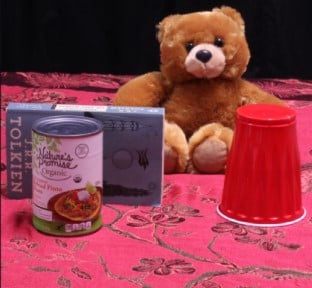

In [1]:
from PIL import Image
scene = Image.open('/kaggle/input/testeser/anhtest.jpg').convert("RGB")
scene

In [ ]:
import os

os.chdir('/kaggle/working/cobl')

# Đọc file
with open('setup.py', 'r') as f:
    content = f.read()

# Sửa python version: Python 3.11.13
content = content.replace(
    'python_requires=">=3.10,<3.11"',
    'python_requires=">=3.10,<3.12"'
)

# Sửa torch: dùng torch 2.6.0 đã có sẵn (không cần tải lại 2.7.1)
content = content.replace(
    '"torch==2.7.1",',
    '"torch>=2.6.0,<2.8.0",'
).replace(
    '"torchaudio==2.7.1",',
    '"torchaudio>=2.6.0,<2.8.0",'
).replace(
    '"torchvision==0.22.1",',
    '"torchvision>=0.21.0,<0.23.0",'
)

# Ghi lại
with open('setup.py', 'w') as f:
    f.write(content)

print("✓ Đã sửa setup.py phù hợp với:")
print("  - Python 3.11.13")
print("  - PyTorch 2.6.0+cu124")
print("  - CUDA 12.4")

In [ ]:
!ls -R /kaggle/working/cobl

In [ ]:
print("📦 Cài xformers cho torch 2.6.0...")

# Cài xformers tương thích với torch 2.6.0 và CUDA 12.4
!pip install -q xformers==0.0.29.post3

print("✓ Đã cài xformers!")

In [ ]:
print("📦 Cài các thư viện còn lại...")

!pip install -q diffusers==0.34.0 einops==0.7.0 kornia==0.8.1
!pip install -q pytorch-lightning==2.5.2 open_clip_torch==2.32.0
!pip install -q opencv-python pillow matplotlib transformers omegaconf
!pip install -q h5py loralib natsort tokenizers torchmetrics tqdm requests
!pip install -q lightning-utilities==0.14.3

print("✓ Đã cài tất cả dependencies!")

In [ ]:
import os

os.chdir('/kaggle/working/cobl')

print("⚙️ Đang cài đặt cobl...")
!pip install -e .

print("\n✓ Cài đặt cobl hoàn tất!")

In [ ]:
import sys
import torch

print("=" * 60)
print("KIỂM TRA SAU KHI CÀI ĐẶT")
print("=" * 60)
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

try:
    import xformers
    print(f"xformers: {xformers.__version__} ✓")
except Exception as e:
    print(f"xformers: ❌ {e}")

try:
    import cobl
    print("cobl: ✓ Đã cài")
except Exception as e:
    print(f"cobl: ❌ {e}")

try:
    import diffusers
    print(f"diffusers: {diffusers.__version__} ✓")
except Exception as e:
    print(f"diffusers: ❌ {e}")

print("=" * 60)

In [ ]:
import os
import requests
from tqdm import tqdm

os.chdir('/kaggle/working/cobl')

def download_file(url, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"✓ {path} đã có ({size_mb:.1f} MB)")
        return
    
    print(f"\n⬇ Đang tải {os.path.basename(path)}...")
    
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    with open(path, 'wb') as f, tqdm(
        total=total_size, 
        unit='iB', 
        unit_scale=True,
        unit_divisor=1024
    ) as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            size = f.write(chunk)
            pbar.update(size)
    
    size_mb = os.path.getsize(path) / (1024**2)
    print(f"✓ Đã tải xong ({size_mb:.1f} MB)")

print("\n📥 TẢI CHECKPOINTS (mất ~5-10 phút)\n")

# 1. Stable Diffusion (~4-5GB)
download_file(
    "https://www.dropbox.com/scl/fi/gigq3jln53alg8aalhsdn/v2-1_512-ema-pruned.ckpt?rlkey=absdglgiw5strfkdociwqdcw9&st=hx4tqbyb&dl=1",
    "cobl/LDM/SD2p1/v2-1_512-ema-pruned.ckpt"
)

# 2. CObL parameters
download_file(
    "https://www.dropbox.com/scl/fi/cirx1dh4hst6ar3o2w33h/cobl_added_params.ckpt?rlkey=2p9lqvqz9ae0djg9uthtari3p&st=sq05l8kn&dl=1",
    "cobl/model/cobl_added_params.ckpt"
)

# 3. U2Net
download_file(
    "https://www.dropbox.com/scl/fi/obpwapfgjl6gwmmwpc1le/u2net.pth?rlkey=0q0dqx17fk9yve3ve98ws9zy9&st=z6uuzf1c&dl=1",
    "cobl/U2Net/u2net.pth"
)

print("\n✅ TẤT CẢ CHECKPOINTS SẴN SÀNG!")

In [ ]:
import os
import torch

os.chdir('/kaggle/working/cobl')

print("🔧 Đang khởi tạo model (có thể mất 1-2 phút)...\n")

from cobl import initialize_diffusion_model

ckpt_path = "cobl/model/cobl_added_params.ckpt"
config_path = "cobl/model/config.yaml"

model = initialize_diffusion_model(config_path, ckpt_path)

print("\n" + "="*60)
print("✅ MODEL ĐÃ SẴN SÀNG!")
print("="*60)
print(f"Device: {next(model.parameters()).device}")
print(f"Model type: {type(model).__name__}")

In [ ]:
from PIL import Image
scene = Image.open('/kaggle/working/cobl/demo/tabletop_sample.png').convert("RGB")
scene

In [ ]:
import torch
import gc
from PIL import Image
from cobl import Guided_Layer_Sampler, plot_obj_layers

# Clear memory hoàn toàn
torch.cuda.empty_cache()
gc.collect()

# Load ảnh
scene = Image.open('/kaggle/working/cobl/demo/tabletop_sample.png').convert("RGB")
scene = scene.resize((384, 384))  # Có thể to hơn với T100

# Seed
seed = 5
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Initial latents
x_start = torch.randn(
    (1, 28, 48, 48),  # Có thể lớn hơn với T100
    dtype=torch.float16,
    device='cuda',
)

print("🚀 Sampling WITHOUT guidance (chỉ cách chạy được)...")

with torch.inference_mode():
    sampler = Guided_Layer_Sampler(model, n_steps=15)
    
    out, logger = sampler.sample(
        x_start=x_start,
        batch_size=1,
        cond=scene,
        use_guidance=False  # <<<< BẮT BUỘC phải False
    )

print("✅ Done!")

# Visualize
plot_obj_layers(scene, sampler, out)